## KNN k-nearest neighbors

In [56]:
import pandas as pd
df=pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [57]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [59]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [60]:
x=df.iloc[:,0:8]
y=df['Outcome']
print(x.shape,y.shape)
# x=df.drop('outcome',axis=1)

(768, 8) (768,)


In [61]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [62]:
from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(n_neighbors=15)
model=nn.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)
# or 
# from sklearn.neighbors import KNeighborsClassifier
# model=KNeighborsClassifier(n_neighbors=15)
# model.fit(x_train,y_train)
# prediction=model.predict(x_test)
# print(prediction)

[1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 0
 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0
 0 0 0 1 0 0]


In [63]:
diff=pd.DataFrame({"Actual":y_test,"predicted":prediction})
diff

,Actual,predicted
285,0,1
101,0,0
581,0,0
352,0,0
726,0,0
...,...,...
563,0,0
318,0,0
154,1,1
684,0,0


In [64]:
diff.to_excel("diabetes_data.xlsx")

### Confusion

In [65]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,prediction)
print(cm)

[[89 10]
 [23 32]]


In [66]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
print(TN,FP,FN,TP)

89 10 23 32


## Accuracy Score

In [16]:
print("Accuracy Score",(TN+TP)/(TN+TP+FN+FP))

Accuracy Score 0.7857142857142857


In [17]:
from sklearn.metrics import accuracy_score
print("Accuracy score",accuracy_score(y_test,prediction))

Accuracy score 0.7857142857142857


## Error Rate

In [20]:
print("error rate",(FN+FP)/(TN+TP+FN+FP))

error rate 0.21428571428571427


In [19]:
print("Error rate",1-accuracy_score(y_test,prediction))

Error rate 0.2142857142857143


## Sensitivity

In [21]:
# positive accuracy cases
print("sensitivity",TP/(TP+FN))

sensitivity 0.5818181818181818


In [23]:
from sklearn.metrics import recall_score
print("Sensitivity",recall_score(y_test,prediction))

Sensitivity 0.5818181818181818


## Specificity

In [22]:
# negtive accuracy cases
print("Specificity",TN/(TN+FP))

Specificity 0.898989898989899


In [24]:
from sklearn.metrics import recall_score
print("Specificity",recall_score(y_test,prediction,pos_label=0))

Specificity 0.898989898989899


## Precision score

In [25]:
# sensitivity reverse
print("Precision",TP/(TP+FP))

Precision 0.7619047619047619


In [26]:
from sklearn.metrics import precision_score
print("precision",precision_score(y_test,prediction))

precision 0.7619047619047619


In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
l=[]
for i in range(1,31):
     nn=KNeighborsClassifier(n_neighbors=i)
     model=nn.fit(x_train,y_train)
     pred=model.predict(x_test)
     l.append(accuracy_score(y_test,pred))
print(l)
print(max(l))

[0.7207792207792207, 0.7272727272727273, 0.7402597402597403, 0.7207792207792207, 0.7337662337662337, 0.7727272727272727, 0.7597402597402597, 0.7662337662337663, 0.7662337662337663, 0.7597402597402597, 0.7467532467532467, 0.7727272727272727, 0.7662337662337663, 0.7727272727272727, 0.7857142857142857, 0.7857142857142857, 0.7857142857142857, 0.7727272727272727, 0.7727272727272727, 0.7727272727272727, 0.7662337662337663, 0.7727272727272727, 0.7662337662337663, 0.7792207792207793, 0.7532467532467533, 0.7727272727272727, 0.7532467532467533, 0.7662337662337663, 0.7662337662337663, 0.7792207792207793]
0.7857142857142857


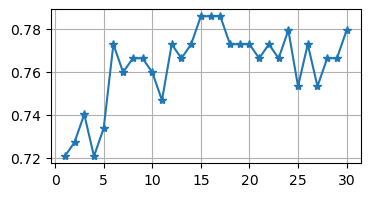

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,2))
plt.plot(range(1,31),l,marker='*')
plt.grid()
plt.show()

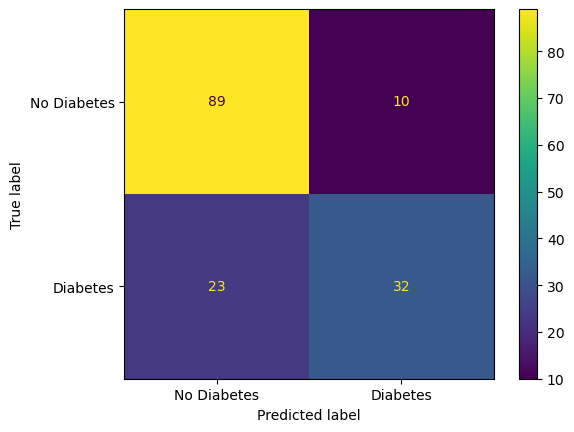

In [47]:
import matplotlib.pyplot as plt
from sklearn import metrics
cm_display=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['No Diabetes','Diabetes'])
cm_display.plot()
plt.show()

### tshirt.csv

In [3]:
import pandas as pd
df=pd.read_csv('tshirt.csv')
df

,Height,Wight,Size
0,158,58,M
1,158,59,M
2,158,63,M
3,160,59,M
4,160,60,M
5,163,60,M
6,163,61,M
7,160,64,L
8,163,64,L
9,165,61,L


In [4]:
x=df[['Height','Wight']]
y=df['Size']
print(x.shape,y.shape)

(18, 2) (18,)


In [5]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(14, 2)
(4, 2)
(14,)
(4,)


In [6]:
from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(n_neighbors=5)
model=nn.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)

['L' 'M' 'L' 'M']


In [7]:
diff=pd.DataFrame({"Actual":y_test,"predicted":prediction})
diff

,Actual,predicted
6,M,L
3,M,M
13,L,L
2,M,M


In [8]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,prediction)
print(cm)

[[1 0]
 [1 2]]


In [9]:
from sklearn.metrics import accuracy_score
print("Accuracy score",accuracy_score(y_test,prediction))

Accuracy score 0.75


In [10]:
print("Error rate",1-accuracy_score(y_test,prediction))

Error rate 0.25


In [11]:
from sklearn.metrics import recall_score
print("Sensitivity",recall_score(y_test,prediction,pos_label="M"))

Sensitivity 0.6666666666666666


In [12]:
from sklearn.metrics import recall_score
print("Specificity",recall_score(y_test,prediction,pos_label="L"))

Specificity 1.0


In [15]:
from sklearn.metrics import precision_score
print("precision",precision_score(y_test,prediction,pos_label="M"))

precision 1.0


In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
l=[]
for i in range(1,10):
     nn=KNeighborsClassifier(n_neighbors=i)
     model=nn.fit(x_train,y_train)
     pred=model.predict(x_test)
     l.append(accuracy_score(y_test,pred))
print(l)
print(max(l))

[0.75, 0.5, 0.75, 0.75, 0.75, 0.75, 0.75, 0.25, 0.25]
0.75


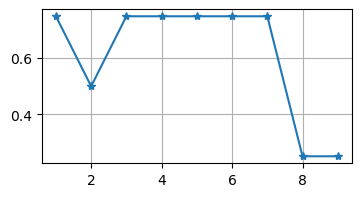

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,2))
plt.plot(range(1,10),l,marker='*')
plt.grid()
plt.show()

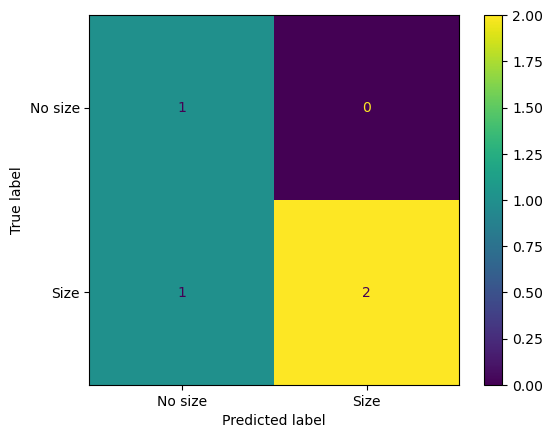

In [19]:
import matplotlib.pyplot as plt
from sklearn import metrics
cm_display=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['No size','Size'])
cm_display.plot()
plt.show()

## AptitudeCommunication.csv

In [20]:
import pandas as pd
df=pd.read_csv('AptitudeCommunication.csv')
df

,Name,Aptitude,Communication,Class
0,Karuna,2,5.0,Speaker
1,Bhuvan,2,6.0,Speaker
2,Gaurav,7,6.0,Leader
3,Parul,7,2.5,Speaker
4,dinesh,8,6.0,Intel
5,Jani,4,7.0,Speaker
6,Bobby,5,3.0,Intel
7,Parimal,3,5.5,Leader
8,Govind,8,3.0,Intel
9,Shushant,6,5.5,Speaker


In [21]:
x=df[['Aptitude','Communication']]
y=df['Class']
print(x.shape,y.shape)

(14, 2) (14,)


In [22]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(11, 2)
(3, 2)
(11,)
(3,)


In [25]:
from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(n_neighbors=5)
model=nn.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)

['Intel' 'Speaker' 'Intel']


In [26]:
diff=pd.DataFrame({"Actual":y_test,"predicted":prediction})
diff

,Actual,predicted
3,Speaker,Intel
7,Leader,Speaker
6,Intel,Intel


In [27]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,prediction)
print(cm)

[[1 0 0]
 [0 0 1]
 [1 0 0]]


In [28]:
from sklearn.metrics import accuracy_score
print("Accuracy score",accuracy_score(y_test,prediction))

Accuracy score 0.3333333333333333


In [29]:
print("Error rate",1-accuracy_score(y_test,prediction))

Error rate 0.6666666666666667


## Entropy & IG

In [58]:
import pandas as pd
df=pd.read_csv('DecisionTreeDataset -Num.csv')
df

,CGPA,Communication,Apptitude,Programming Skill,Job Offered
0,2,1,1,1,1
1,1,1,1,1,1
2,0,0,0,1,0
3,0,1,0,0,0
4,2,1,1,0,1
5,2,1,1,1,1
6,1,0,0,0,0
7,1,0,0,1,0
8,2,0,1,1,1
9,1,1,1,1,1


In [59]:
x=df[['CGPA','Communication','Apptitude','Programming Skill']]
y=df['Job Offered']
print(x.shape,y.shape)

(18, 4) (18,)


In [60]:
x.columns

Index(['CGPA', 'Communication', 'Apptitude', 'Programming Skill'], dtype='object')

In [61]:
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(criterion='entropy')
model=dtree.fit(x,y)
pred=model.predict(x)
print(pred)

[1 1 0 0 1 1 0 0 1 1 0 0 1 0 0 0 0 1]


In [62]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,pred)
print(cm)

[[10  0]
 [ 0  8]]


In [63]:
from sklearn.metrics import accuracy_score
print("Accuracy score",accuracy_score(y,pred))

Accuracy score 1.0


In [64]:
from sklearn import tree
text_representation=tree.export_text(dtree)
print(text_representation)

|--- feature_2 <= 0.50
|   |--- class: 0
|--- feature_2 >  0.50
|   |--- feature_1 <= 0.50
|   |   |--- feature_0 <= 1.50
|   |   |   |--- class: 0
|   |   |--- feature_0 >  1.50
|   |   |   |--- class: 1
|   |--- feature_1 >  0.50
|   |   |--- class: 1



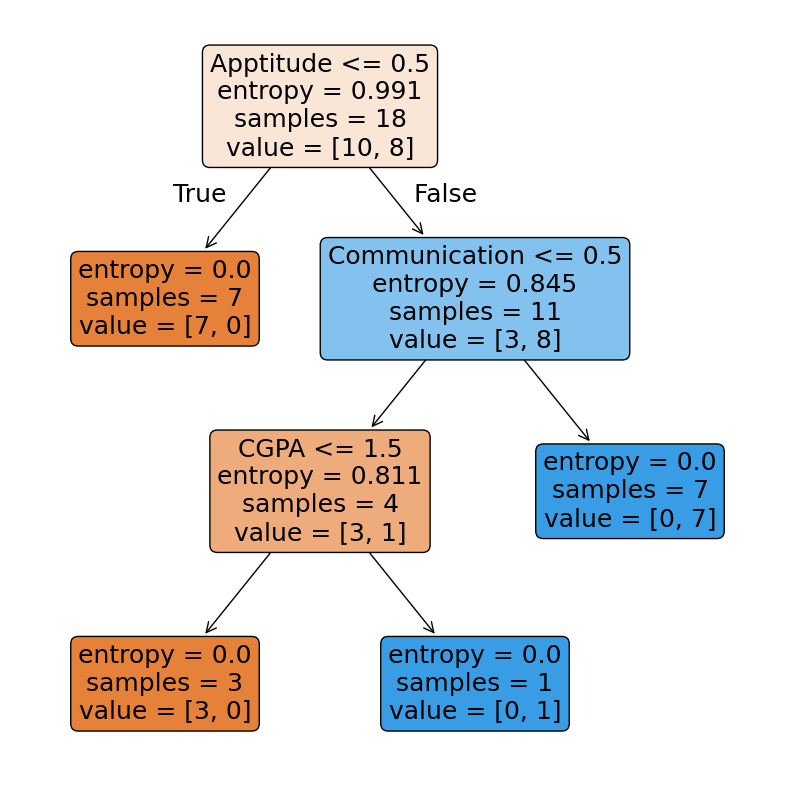

In [65]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(10,10))
plot_tree(dtree,feature_names=x.columns,filled=True,rounded=True)
plt.show()

### DecisionTree_Sports.csv

In [38]:
import pandas as pd
df=pd.read_csv('DecisionTree_Sports.csv')
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,Sunny,Hot,High,Weak,No
1,Day 2,Sunny,Hot,High,Strong,No
2,Day 3,Cloudy,Hot,High,Weak,Yes
3,Day 4,Rain,Mild,High,Weak,Yes
4,Day 5,Rain,Cool,Normal,Weak,Yes
5,Day 6,Rain,Cool,Normal,Strong,No
6,Day 7,Cloudy,Cool,Normal,Strong,Yes
7,Day 8,Sunny,Mild,High,Weak,No
8,Day 9,Sunny,Cool,Normal,Weak,Yes
9,Day 10,Rain,Mild,Normal,Weak,Yes


In [39]:
df.drop("Day",axis=1,inplace=True)
df

,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Cloudy,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Cloudy,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [40]:
import numpy as np
df['Weather']=np.where(df['Weather']=='Cloudy',0,np.where(df['Weather']=='Rain',1,2))
df

,Weather,Temperature,Humidity,Wind,Play_Sports?
0,2,Hot,High,Weak,No
1,2,Hot,High,Strong,No
2,0,Hot,High,Weak,Yes
3,1,Mild,High,Weak,Yes
4,1,Cool,Normal,Weak,Yes
5,1,Cool,Normal,Strong,No
6,0,Cool,Normal,Strong,Yes
7,2,Mild,High,Weak,No
8,2,Cool,Normal,Weak,Yes
9,1,Mild,Normal,Weak,Yes


In [41]:
import numpy as np
df['Temperature']=np.where(df['Temperature']=='Cool',0,np.where(df['Temperature']=='Hot',1,2))
df

,Weather,Temperature,Humidity,Wind,Play_Sports?
0,2,1,High,Weak,No
1,2,1,High,Strong,No
2,0,1,High,Weak,Yes
3,1,2,High,Weak,Yes
4,1,0,Normal,Weak,Yes
5,1,0,Normal,Strong,No
6,0,0,Normal,Strong,Yes
7,2,2,High,Weak,No
8,2,0,Normal,Weak,Yes
9,1,2,Normal,Weak,Yes


In [42]:
import numpy as np
df['Humidity']=np.where(df['Humidity']=='High',0,1)
df

,Weather,Temperature,Humidity,Wind,Play_Sports?
0,2,1,0,Weak,No
1,2,1,0,Strong,No
2,0,1,0,Weak,Yes
3,1,2,0,Weak,Yes
4,1,0,1,Weak,Yes
5,1,0,1,Strong,No
6,0,0,1,Strong,Yes
7,2,2,0,Weak,No
8,2,0,1,Weak,Yes
9,1,2,1,Weak,Yes


In [43]:
import numpy as np
df['Wind']=np.where(df['Wind']=='Strong',0,1)
df

,Weather,Temperature,Humidity,Wind,Play_Sports?
0,2,1,0,1,No
1,2,1,0,0,No
2,0,1,0,1,Yes
3,1,2,0,1,Yes
4,1,0,1,1,Yes
5,1,0,1,0,No
6,0,0,1,0,Yes
7,2,2,0,1,No
8,2,0,1,1,Yes
9,1,2,1,1,Yes


In [44]:
import numpy as np
df['Play_Sports?']=np.where(df['Play_Sports?']=='Yes',1,0)
df

,Weather,Temperature,Humidity,Wind,Play_Sports?
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1
5,1,0,1,0,0
6,0,0,1,0,1
7,2,2,0,1,0
8,2,0,1,1,1
9,1,2,1,1,1


In [45]:
x=df[['Weather','Temperature','Humidity','Wind']]
y=df['Play_Sports?']
print(x.shape,y.shape)
# x=df.iloc[:,:4]
# y=df.iloc[:,-1]

(14, 4) (14,)


In [46]:
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(criterion='entropy')
model=dtree.fit(x,y)
pred=model.predict(x)
print(pred)

[0 0 1 1 1 0 1 0 1 1 1 1 1 0]


In [49]:
from sklearn import tree
text_representation=tree.export_text(dtree)
print(text_representation)

|--- feature_0 <= 0.50
|   |--- class: 1
|--- feature_0 >  0.50
|   |--- feature_2 <= 0.50
|   |   |--- feature_0 <= 1.50
|   |   |   |--- feature_3 <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_3 >  0.50
|   |   |   |   |--- class: 1
|   |   |--- feature_0 >  1.50
|   |   |   |--- class: 0
|   |--- feature_2 >  0.50
|   |   |--- feature_3 <= 0.50
|   |   |   |--- feature_0 <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_0 >  1.50
|   |   |   |   |--- class: 1
|   |   |--- feature_3 >  0.50
|   |   |   |--- class: 1



In [51]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,pred)
print(cm)

[[5 0]
 [0 9]]


In [52]:
from sklearn.metrics import accuracy_score
print("Accuracy score",accuracy_score(y,pred))

Accuracy score 1.0


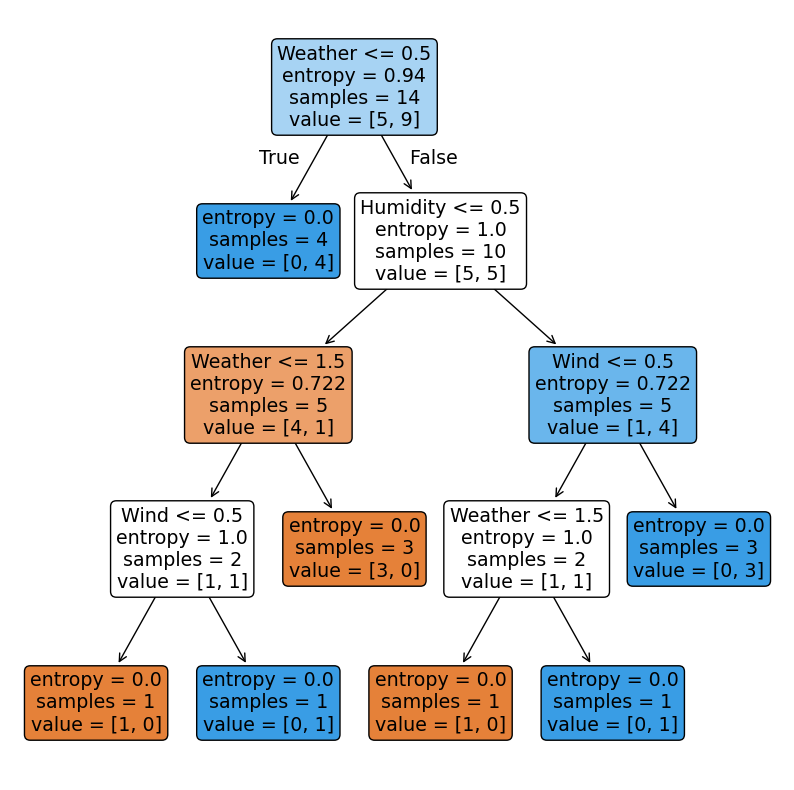

In [54]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(10,10))
plot_tree(dtree,feature_names=x.columns,filled=True,rounded=True)
plt.show()

In [56]:
df.to_excel('DecisionTree_Sports.xlsx')

### Get_dummies use

In [1]:
import pandas as pd
df=pd.read_csv('DecisionTree_Sports.csv')
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,Sunny,Hot,High,Weak,No
1,Day 2,Sunny,Hot,High,Strong,No
2,Day 3,Cloudy,Hot,High,Weak,Yes
3,Day 4,Rain,Mild,High,Weak,Yes
4,Day 5,Rain,Cool,Normal,Weak,Yes
5,Day 6,Rain,Cool,Normal,Strong,No
6,Day 7,Cloudy,Cool,Normal,Strong,Yes
7,Day 8,Sunny,Mild,High,Weak,No
8,Day 9,Sunny,Cool,Normal,Weak,Yes
9,Day 10,Rain,Mild,Normal,Weak,Yes


In [2]:
df.drop("Day",axis=1,inplace=True)
df

,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Cloudy,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Cloudy,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [3]:
x=df[['Weather','Temperature','Humidity','Wind']]
y=df['Play_Sports?']
print(x.shape,y.shape)

(14, 4) (14,)


In [4]:
x.columns

Index(['Weather', 'Temperature', 'Humidity', 'Wind'], dtype='object')

In [6]:
x=pd.get_dummies(data=x)
x

,Weather_Cloudy,Weather_Rain,Weather_Sunny,Temperature_Cool,Temperature_Hot,Temperature_Mild,Humidity_High,Humidity_Normal,Wind_Strong,Wind_Weak
0,False,False,True,False,True,False,True,False,False,True
1,False,False,True,False,True,False,True,False,True,False
2,True,False,False,False,True,False,True,False,False,True
3,False,True,False,False,False,True,True,False,False,True
4,False,True,False,True,False,False,False,True,False,True
5,False,True,False,True,False,False,False,True,True,False
6,True,False,False,True,False,False,False,True,True,False
7,False,False,True,False,False,True,True,False,False,True
8,False,False,True,True,False,False,False,True,False,True
9,False,True,False,False,False,True,False,True,False,True


In [7]:
import numpy as np
y=np.where(y=='No',0,1)
y

array([0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0])

In [8]:
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(criterion='entropy')
model=dtree.fit(x,y)
pred=model.predict(x)
print(pred)

[0 0 1 1 1 0 1 0 1 1 1 1 1 0]


In [9]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,pred)
print(cm)

[[5 0]
 [0 9]]


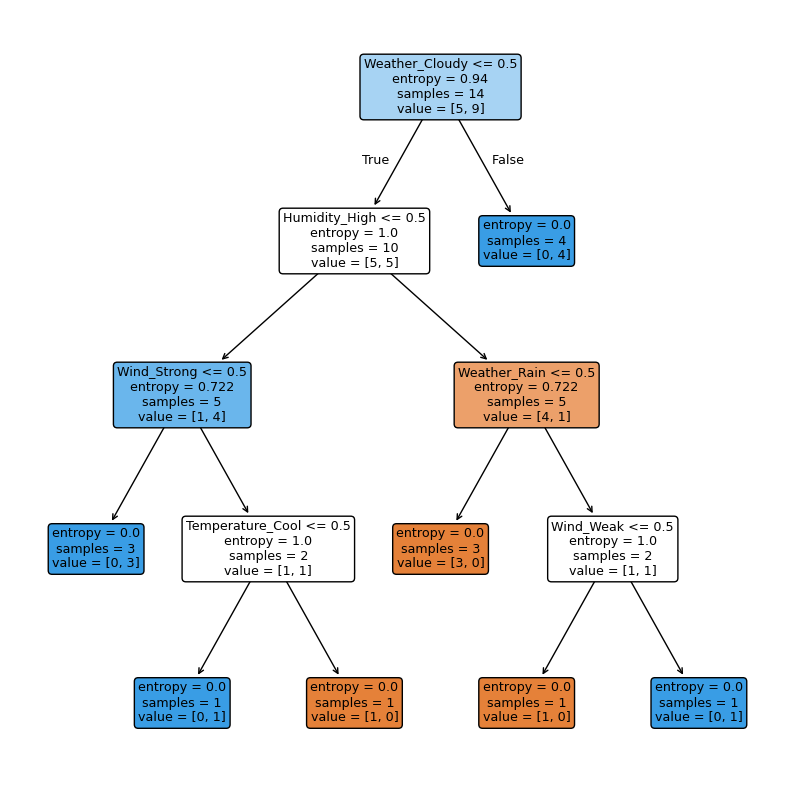

In [10]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(10,10))
plot_tree(dtree,feature_names=x.columns,filled=True,rounded=True)
plt.show()

In [11]:
dtree.get_depth()

4

# Random 

In [3]:
import pandas as pd
df = pd.read_csv("titanic.csv")

In [4]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [5]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
import numpy as np
df['Sex']=np.where(df['Sex']=='male',1,0)

In [25]:
#df['Sex']=df['Sex'].map({'female':0,'male':1})

In [8]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [9]:
x=df[['Pclass','Sex', 'Age', 'SibSp','Parch','Fare']]
y=df['Survived']
print(x.shape,y.shape)

(891, 6) (891,)


In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 6)
(179, 6)
(712,)
(179,)


In [11]:
from sklearn.ensemble import RandomForestClassifier
rf= RandomForestClassifier(criterion='entropy',n_estimators=100,random_state=1)
model=rf.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(y_pred)

[1 0 1 0 1 0 0 1 0 1 0 0 0 0 1 1 0 0 0 1 1 0 1 0 1 0 1 1 0 1 0 1 1 0 0 0 1
 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 0 0 1 0 0 1
 0 0 0 0 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0 0 0 0 0
 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 0 1 0 1 0 1 0 0 0 1]


In [12]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[96 10]
 [28 45]]


In [13]:
from sklearn.metrics import accuracy_score
print("Accuracy score",accuracy_score(y_test,y_pred))

Accuracy score 0.7877094972067039


In [14]:
from sklearn.metrics import recall_score
print("Sensitivity",recall_score(y_test,y_pred,pos_label=1))

Sensitivity 0.6164383561643836


In [15]:
from sklearn.metrics import recall_score
print("Specificity",recall_score(y_test,y_pred,pos_label=0))

Specificity 0.9056603773584906


In [16]:
from sklearn.metrics import precision_score
print("precision",precision_score(y_test,y_pred,pos_label=1))

precision 0.8181818181818182


In [17]:
sample = x_test.iloc[0:1]
print(sample)
prediction=model.predict(sample)
print(f"Predicted Survival:{'Survived' if prediction[0]==1 else 'Not survived'}")

     Pclass  Sex   Age  SibSp  Parch     Fare
862       1    0  48.0      0      0  25.9292
Predicted Survival:Survived


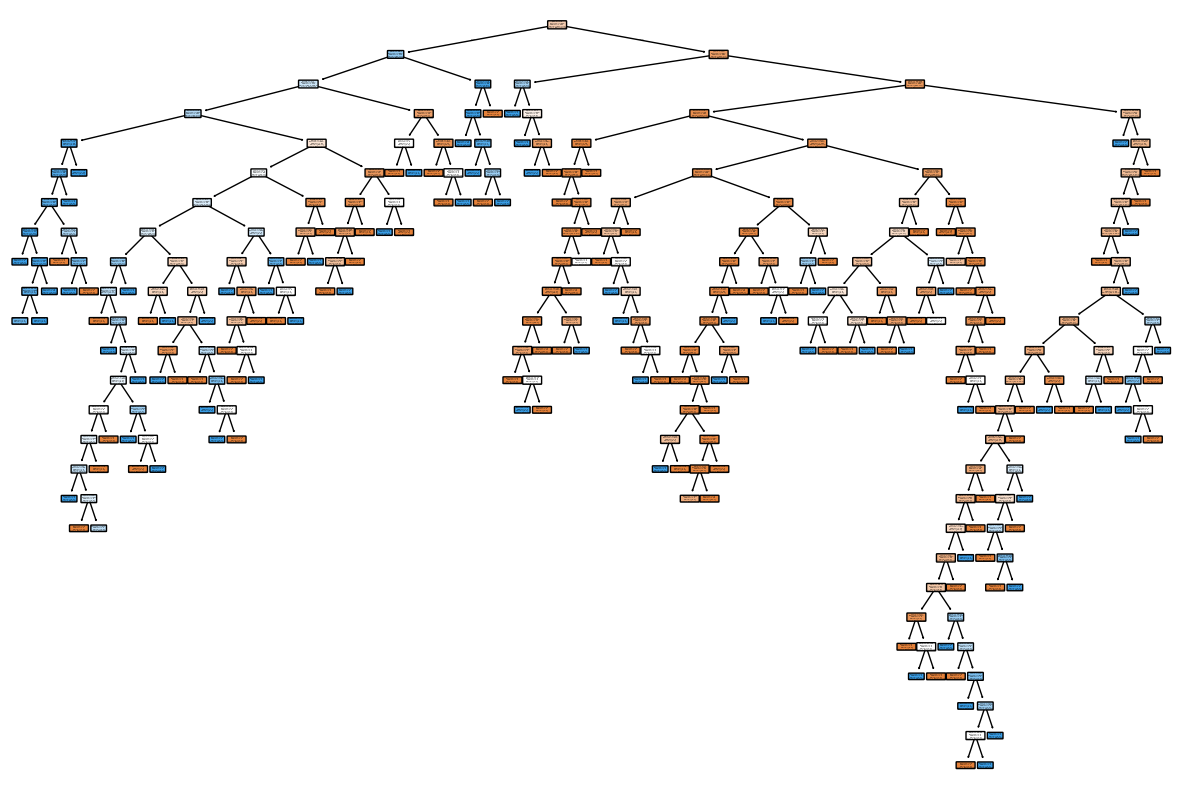

In [18]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
choose_tree=model.estimators_[0]
plt.figure(figsize=(15,10))
plot_tree(choose_tree,feature_names=['Pclass','Sex', 'Age', 'SibSp','Parch','Fare'],
          class_names=['Not survived','Survived'],filled=True,rounded=True,max_depth=100)
plt.show()

In [19]:
df=pd.DataFrame({"Weight":[150,170,140,180,160,155],"Texture":['S','R','S','R','S','R',],
                 "Color":['R','O','G','O','R','Y'],"Fruit":['A','O','A','O','A','O']})
df

,Weight,Texture,Color,Fruit
0,150,S,R,A
1,170,R,O,O
2,140,S,G,A
3,180,R,O,O
4,160,S,R,A
5,155,R,Y,O


In [20]:
import numpy as np
df['Texture']=np.where(df['Texture']=='S',0,1)
df['Color']=np.where(df['Color']=='R',0,np.where(df['Color']=='O',1,np.where(df['Color']=='G',2,3)))
df

,Weight,Texture,Color,Fruit
0,150,0,0,A
1,170,1,1,O
2,140,0,2,A
3,180,1,1,O
4,160,0,0,A
5,155,1,3,O


In [21]:
x=df[['Weight','Texture', 'Color']]
y=df['Fruit']
print(x.shape,y.shape)

(6, 3) (6,)


In [22]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(4, 3)
(2, 3)
(4,)
(2,)


In [23]:
from sklearn.ensemble import RandomForestClassifier
rf= RandomForestClassifier(criterion='entropy',n_estimators=10,random_state=1)
model=rf.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(y_pred)

['A' 'O']


In [24]:
sample = x_test.iloc[0:1]
print(sample)
prediction=model.predict(sample)
print(f"Fruit:{'Apple' if prediction[0]=='A' else 'Orange'}")

   Weight  Texture  Color
2     140        0      2
Fruit:Apple


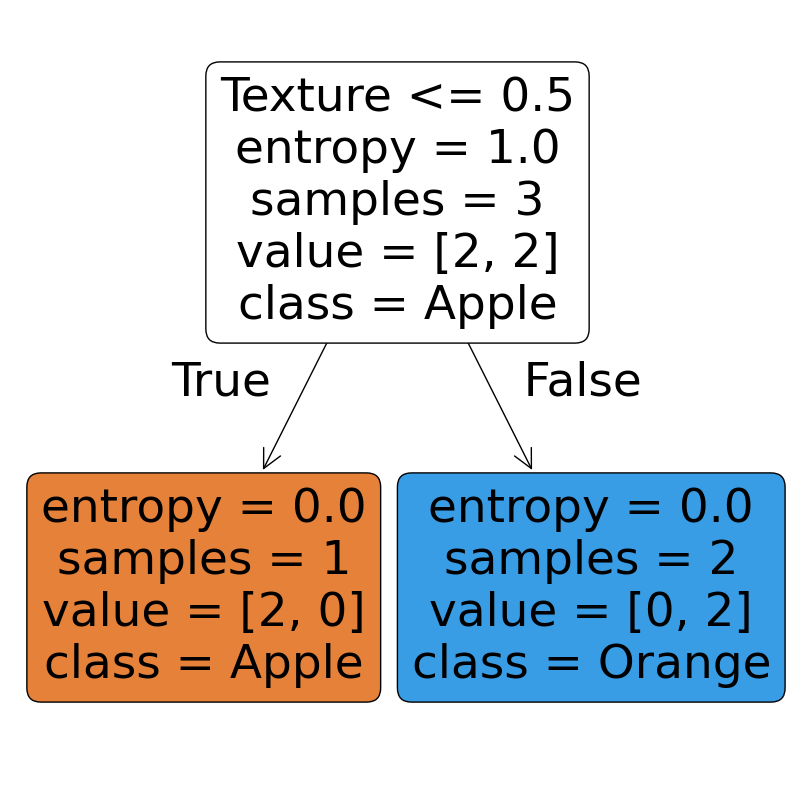

In [25]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
choose_tree=model.estimators_[2]
plt.figure(figsize=(10,10))
plot_tree(choose_tree,feature_names=['Weight','Texture','Color'],
          class_names=['Apple','Orange'],filled=True,rounded=True)
plt.show()

In [26]:
import pandas as pd
df=pd.read_csv('diabetes.csv')

In [27]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [28]:
x=df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']]
y=df['Outcome']

In [29]:
print(x.shape,y.shape)

(768, 8) (768,)


In [30]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [31]:
from sklearn.svm import SVC
classifier=SVC(kernel='rbf',C=1.0,random_state=0)
model=classifier.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)

[0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 1 1 1 0 0
 1 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0
 0 0 0 1 0 0]


In [32]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,prediction)
print(cm)

[[93  6]
 [27 28]]


In [33]:
from sklearn.metrics import accuracy_score
print("Accuracy score",accuracy_score(y_test,prediction))

Accuracy score 0.7857142857142857
